In [ ]:
import pandas as pd
import numpy as np  





In [ ]:
# Import the Bank Churn dataset
churn = pd.read_csv(r'C:\datasets\Bank_Churn.csv')
print(churn.head())
print(f"Dataset shape: {churn.shape}") 

   CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0    15634602  Hargrave          619    France  Female   42       2   
1    15647311      Hill          608     Spain  Female   41       1   
2    15619304      Onio          502    France  Female   42       8   
3    15701354      Boni          699    France  Female   39       1   
4    15737888  Mitchell          850     Spain  Female   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1        101348.88   
1   83807.86              1          0               1        112542.58   
2  159660.80              3          1               0        113931.57   
3       0.00              2          0               0         93826.63   
4  125510.82              1          1               1         79084.10   

   Exited  
0       1  
1       0  
2       1  
3       0  
4       0  
Dataset shape: (10000, 13)


In [4]:
print(churn.info())
print('-------------------------------------------')
print(churn.isnull().sum())
print('-'*30)
print('any duplicated value:',churn.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB
None
-------------------------------------------
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gend

In [4]:
print(churn['Exited'].value_counts())
print(churn['Tenure'].value_counts())
print('-'* 30)
print(churn['Geography'].value_counts())
print('-'* 30)
print(churn['HasCrCard'].value_counts)




Exited
0    7963
1    2037
Name: count, dtype: int64
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64
------------------------------
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
------------------------------
<bound method IndexOpsMixin.value_counts of 0       1
1       0
2       1
3       0
4       1
       ..
9995    1
9996    1
9997    0
9998    1
9999    1
Name: HasCrCard, Length: 10000, dtype: int64>


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')



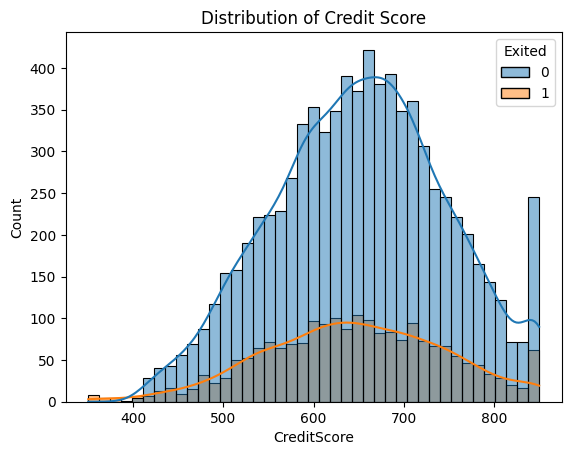

In [5]:
sns.histplot( x ='CreditScore', data = churn, kde = True ,hue = 'Exited') 
plt.title('Distribution of Credit Score')
plt.show()

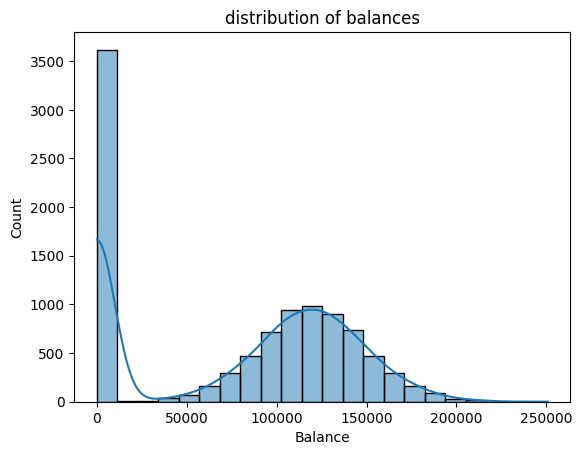

In [9]:
#basic visualization
sns.histplot( x= 'Balance', data =churn ,  kde = True)
plt.title('distribution of balances')
plt.show()

[]

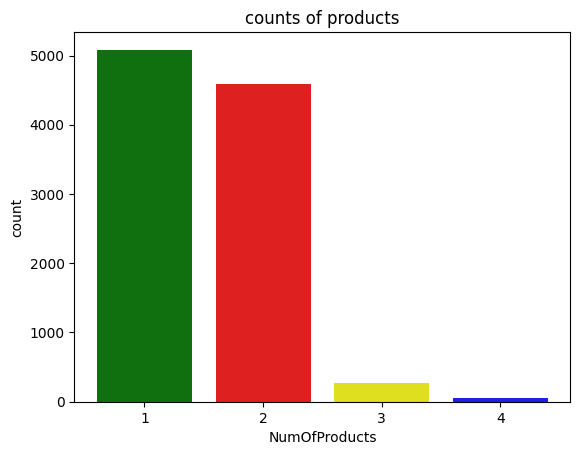

In [ ]:
sns.countplot(x = 'NumOfProducts', 
              data = churn, 
              palette= ['green','red','yellow','blue'], 
              legend= True
              )
plt.title('counts of products')
plt.plot()

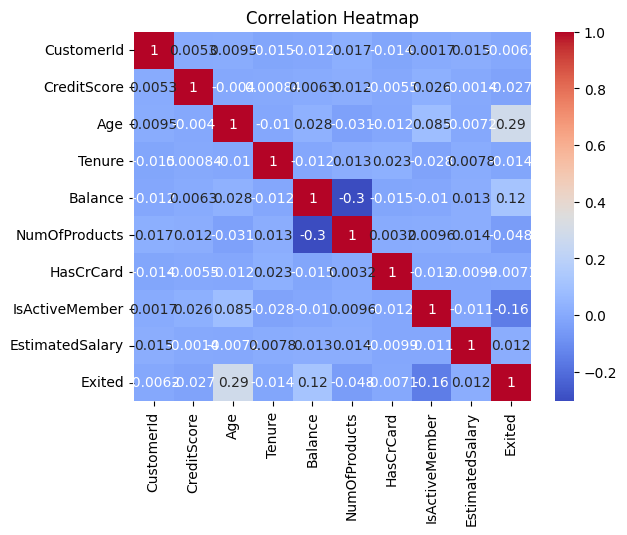

In [6]:

numeric_churn = churn.select_dtypes(include=np.number)
sns.heatmap(numeric_churn.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [3]:
#feature engineering 
churn['Balance_to_Salary_Ratio'] = churn['Balance'] / (churn['EstimatedSalary'] + 1)

def tenure_category(tenure):

    if tenure == 0:
        return ' less than a year'
    elif tenure > 0 and tenure <= 3:
        return 'low'
    elif tenure > 3 and tenure <= 6:
        return 'mid'
    else:
        return 'High'
    

churn['tenure_category'] = churn['Tenure'].apply(tenure_category)
churn['High_Risk_Product_Count'] = churn['NumOfProducts'].apply(lambda x: 1 if x >= 3 else 0)
churn['Credit_Score_by_Age'] = churn['CreditScore'] / churn['Age']

print('-'*60)
print(churn.columns)
print('-'*60)
print(churn[['Balance_to_Salary_Ratio', 'tenure_category', 'High_Risk_Product_Count', 'Credit_Score_by_Age']].head(5))




------------------------------------------------------------
Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Balance_to_Salary_Ratio',
       'tenure_category', 'High_Risk_Product_Count', 'Credit_Score_by_Age'],
      dtype='object')
------------------------------------------------------------
   Balance_to_Salary_Ratio tenure_category  High_Risk_Product_Count  \
0                 0.000000             low                        0   
1                 0.744670             low                        0   
2                 1.401362            High                        1   
3                 0.000000             low                        0   
4                 1.587035             low                        0   

   Credit_Score_by_Age  
0            14.738095  
1            14.829268  
2            11.952381  
3            17.923077  
4          

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numerical features you plan to feed into the model
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                      'EstimatedSalary', 'Balance_to_Salary_Ratio', 'Credit_Score_by_Age']

X_vif = churn[numerical_features].dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                   Feature         VIF
0              CreditScore  135.896712
7      Credit_Score_by_Age   53.508657
1                      Age   40.005851
4            NumOfProducts    8.186928
5          EstimatedSalary    3.966819
2                   Tenure    3.933522
3                  Balance    2.687026
6  Balance_to_Salary_Ratio    1.005233


In [5]:
from sklearn.model_selection import train_test_split

X = churn.drop(columns= ['CustomerId', 'Surname', 'Exited'])
y = churn['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

#one hot encoding 
X_train_encoded = pd.get_dummies(X_train, columns=['Geography', 'Gender','tenure_category'], drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=['Geography', 'Gender','tenure_category'], drop_first=True, dtype=int)


# 5. Verification Check
print("=== POST-ENCODING COMPLIANCE CHECK ===")
print(f"Training features shape: {X_train_encoded.shape}")
print(f"Testing features shape: {X_test_encoded.shape}")
print("\nFirst 3 rows of processed training data:")
print(X_train_encoded.head(3))


=== POST-ENCODING COMPLIANCE CHECK ===
Training features shape: (8000, 17)
Testing features shape: (2000, 17)

First 3 rows of processed training data:
      CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
2151          753   57       7       0.00              1          1   
8392          739   32       3  102128.27              1          1   
5006          755   37       0  113865.23              2          1   

      IsActiveMember  EstimatedSalary  Balance_to_Salary_Ratio  \
2151               0        159475.08                 0.000000   
8392               0         63981.37                 1.596194   
5006               1        117396.25                 0.969914   

      High_Risk_Product_Count  Credit_Score_by_Age  Geography_Germany  \
2151                        0            13.210526                  0   
8392                        0            23.093750                  1   
5006                        0            20.405405                  1   

     

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)





In [7]:
from sklearn.svm import SVC 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score




model_SVC = SVC(kernel = 'poly', degree = 3, random_state =42)
model_SVC.fit(X_train_scaled, y_train)
y_pred_SVC = model_SVC.predict(X_test_scaled)

print("=== SVC CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_SVC))
print("=== SVC CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred_SVC))
print("=== SVC ACCURACY SCORE ===")
print(accuracy_score(y_test, y_pred_SVC)*100,'%')



=== SVC CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1593
           1       0.85      0.35      0.49       407

    accuracy                           0.85      2000
   macro avg       0.85      0.67      0.71      2000
weighted avg       0.85      0.85      0.83      2000

=== SVC CONFUSION MATRIX ===
[[1568   25]
 [ 265  142]]
=== SVC ACCURACY SCORE ===
85.5 %


In [8]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=300,
                                   random_state=42,
                                   class_weight='balanced',
                                   max_depth=10,
                                   min_samples_split=5)
rf_model.fit(X_train_encoded , y_train)
y_pred_rf = rf_model.predict(X_test_encoded)
print("=== RANDOM FOREST CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_rf))
print("=== RANDOM FOREST CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred_rf))
print("=== RANDOM FOREST ACCURACY SCORE ===")
print(accuracy_score(y_test, y_pred_rf)*100,'%')

=== RANDOM FOREST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.54      0.70      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000

=== RANDOM FOREST CONFUSION MATRIX ===
[[1351  242]
 [ 122  285]]
=== RANDOM FOREST ACCURACY SCORE ===
81.8 %


In [9]:
from sklearn.model_selection import GridSearchCV 

param_grid = {
    'n_estimators': [150, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt', 0.5]
     # 0.5 inspects half the features per split to reduce variance
} 

GrSearch = GridSearchCV( estimator= RandomForestClassifier(class_weight= 'balanced',
                                                           random_state= 42),
                        param_grid= param_grid ,
                        scoring = 'f1',
                        cv = 5,
                        n_jobs =-1
                        
)
GrSearch.fit(X_train_encoded,y_train)

best_rf = GrSearch.best_estimator_
y_pred_final = best_rf.predict(X_test_encoded)
print("=== OPTIMIZED HYPERPARAMETERS ===")
print(GrSearch.best_params_)
print(classification_report(y_test, y_pred_final))

=== OPTIMIZED HYPERPARAMETERS ===
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1593
           1       0.53      0.70      0.60       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000



In [12]:


import os

# --- GENERATING ENTERPRISE PREDICTIVE METRICS ---
print("--- GENERATING ENTERPRISE PREDICTIVE METRICS ---")

churn['Churn_Probability'] = best_rf.predict_proba(X_full_encoded)[:, 1]

def assign_risk_tier(prob):
    if prob >= 0.70: return 'High Risk (Red)'
    elif prob >= 0.40: return 'Medium Risk (Amber)'
    else: return 'Low Risk (Green)'

churn['Risk_Segmentation'] = churn['Churn_Probability'].apply(assign_risk_tier)  

# --- THE ABSOLUTE BYPASS FIX ---
# 1. Change the filename completely to break any ghost background locks
# 2. Use a generic name that won't conflict with system rules
fallback_filename = "Final_Bank_Churn_Predictions_v1.csv"

try:
    # Attempt to save locally with the fresh filename
    churn.to_csv(fallback_filename, index=False)
    print(f"\n✔ SUCCESS: File saved cleanly locally!")
    print(f"Path: {os.path.abspath(fallback_filename)}")
except PermissionError:
    # If your current notebook directory is completely locked down, save it straight to your user home folder
    home_fallback = os.path.join(os.path.expanduser("~"), fallback_filename)
    churn.to_csv(home_fallback, index=False)
    print(f"\n✔ EMERGENCY FALLBACK SUCCESS: Directory permissions restricted.")
    print(f"Saved safely to your User Home Folder: {home_fallback}")

print("\n--- NEW VISUAL LAYOUT COLUMNS PREVIEW ---")
print(churn[['Surname', 'Geography', 'Balance', 'Churn_Probability', 'Risk_Segmentation']].head(5))

--- GENERATING ENTERPRISE PREDICTIVE METRICS ---

✔ EMERGENCY FALLBACK SUCCESS: Directory permissions restricted.
Saved safely to your User Home Folder: C:\Users\kaushik\Final_Bank_Churn_Predictions_v1.csv

--- NEW VISUAL LAYOUT COLUMNS PREVIEW ---
    Surname Geography    Balance  Churn_Probability    Risk_Segmentation
0  Hargrave    France       0.00           0.651346  Medium Risk (Amber)
1      Hill     Spain   83807.86           0.404291  Medium Risk (Amber)
2      Onio    France  159660.80           0.986294      High Risk (Red)
3      Boni    France       0.00           0.192575     Low Risk (Green)
4  Mitchell     Spain  125510.82           0.282127     Low Risk (Green)
